In [46]:
import pandas as pd

# Load data
gold = pd.read_csv('C:/Users/University/DATA SCI & BUSINESS/Processed_data/Gold_Import_TradeData_clean_final.csv')
dxy = pd.read_csv('C:/Users//University/DATA SCI & BUSINESS/Processed_data/US_Dollar_Index_cleaned.csv')

# Parse dates
gold['date'] = pd.to_datetime(gold['date'])
dxy['Date']  = pd.to_datetime(dxy['Date'])

# Make cifvalue numeric
gold['cifvalue'] = pd.to_numeric(gold['cifvalue'], errors='coerce')

# 1) Identify top 10 reporter countries by total cifvalue
country_totals = (
    gold.groupby('reporterdesc', dropna=True)['cifvalue']
        .sum()
        .sort_values(ascending=False)
)

top10_countries = country_totals.head(10).index.tolist()
print("Top 10 countries by total cifvalue:")
print(country_totals.head(10))

# 2) Filter gold data to those top 10 countries
gold_top10 = gold[gold['reporterdesc'].isin(top10_countries)].copy()

# 3) Build monthly cifvalue per country
gold_top10['month'] = gold_top10['date'].dt.to_period('M')

country_monthly = (
    gold_top10
    .groupby(['reporterdesc', 'month'])['cifvalue']
    .sum()
    .reset_index()
)

# 4) Build monthly DXY (average per month)
dxy['month'] = dxy['Date'].dt.to_period('M')
dxy_monthly = (
    dxy.groupby('month')['Price']
       .mean()
       .reset_index()
)

# 5) Merge per country and compute Pearson correlation (cifvalue vs DXY)
results = []
for country in top10_countries:
    tmp = country_monthly[country_monthly['reporterdesc'] == country]
    tmp = tmp.merge(dxy_monthly, on='month', how='inner')
    
    if tmp['cifvalue'].notna().sum() > 1 and tmp['Price'].notna().sum() > 1:
        corr_val = tmp[['cifvalue', 'Price']].corr(method='pearson').iloc[0, 1]
    else:
        corr_val = float('nan')
    
    results.append({
        'reporteriso': country,
        'corr_cifvalue_price': corr_val,
        'n_months': len(tmp)
    })

country_corr = pd.DataFrame(results).sort_values('corr_cifvalue_price')
country_corr


Top 10 countries by total cifvalue:
reporterdesc
Switzerland             5.490598e+11
United Kingdom          3.792587e+11
China                   3.738919e+11
United Arab Emirates    2.538223e+11
India                   2.456707e+11
China, Hong Kong SAR    2.252196e+11
Türkiye                 1.095106e+11
USA                     9.893050e+10
Singapore               8.908427e+10
Thailand                5.501554e+10
Name: cifvalue, dtype: float64


,reporteriso,corr_cifvalue_price,n_months
4,India,0.080787,6
7,USA,0.121458,6
1,United Kingdom,0.181546,6
8,Singapore,0.202748,6
9,Thailand,0.443629,6
0,Switzerland,0.473204,6
3,United Arab Emirates,0.561803,5
2,China,0.631745,6
6,Türkiye,0.703835,6
5,"China, Hong Kong SAR",0.751278,6


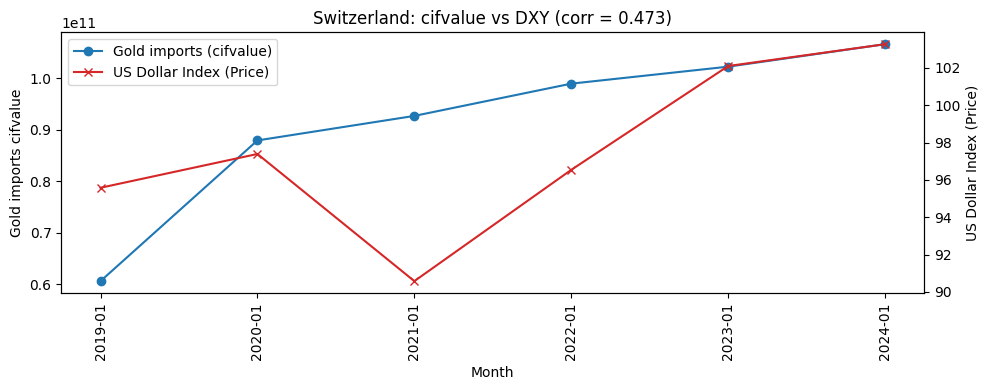

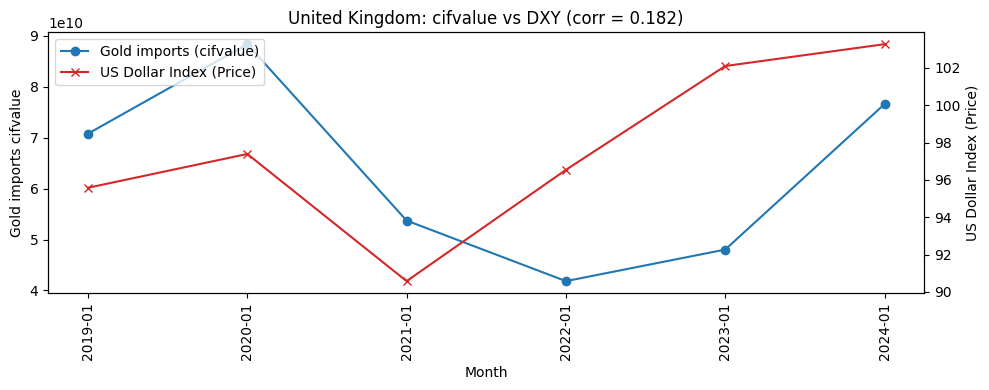

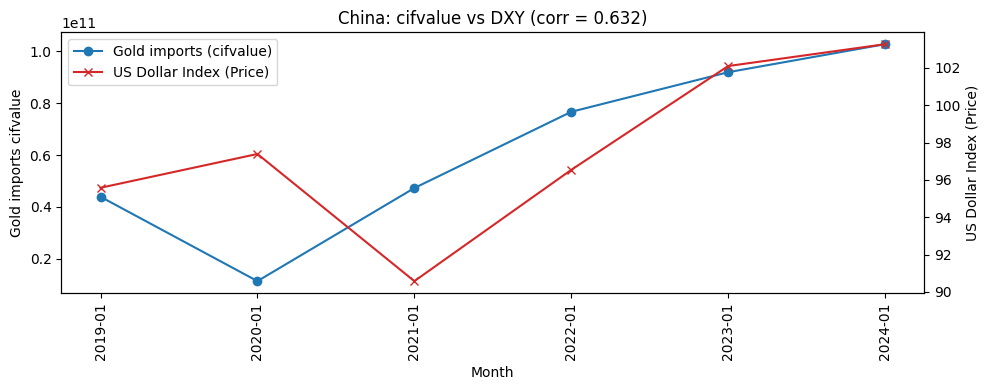

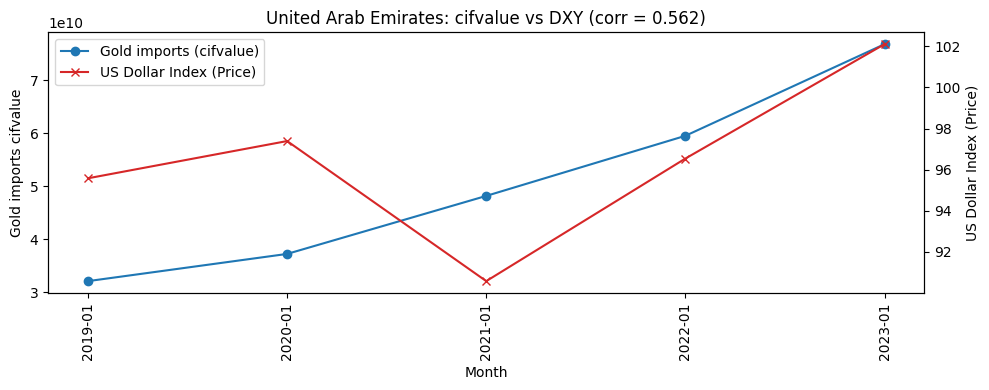

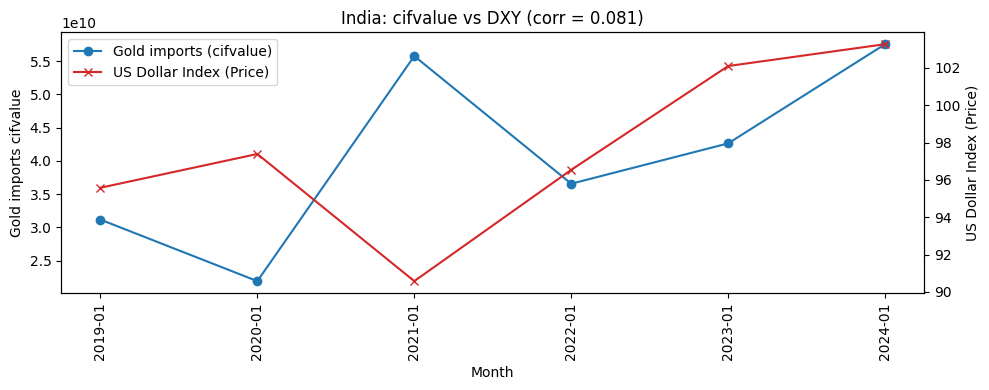

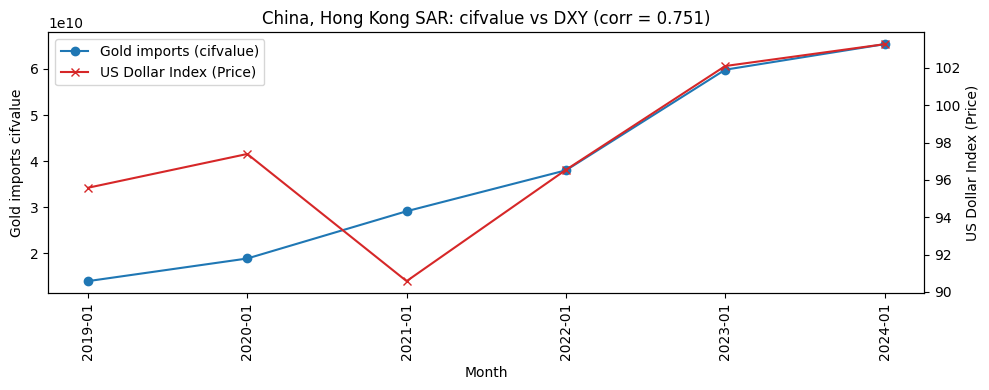

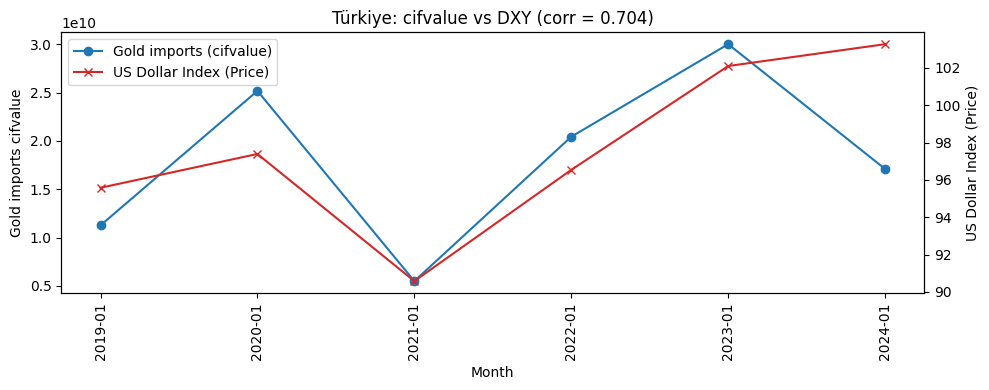

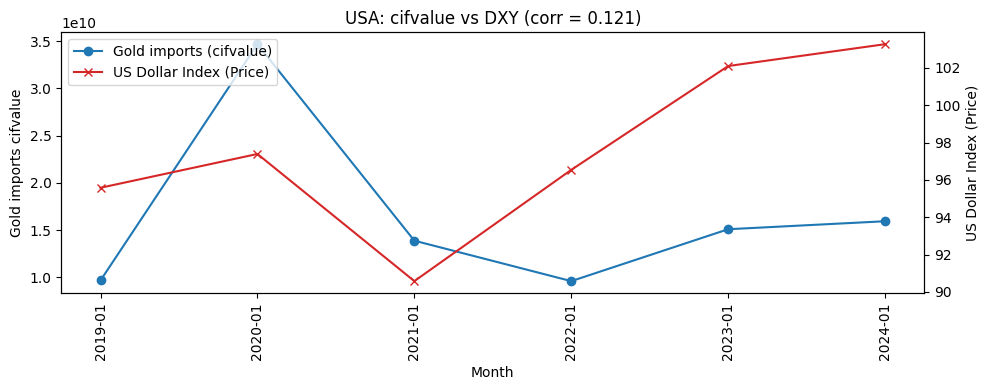

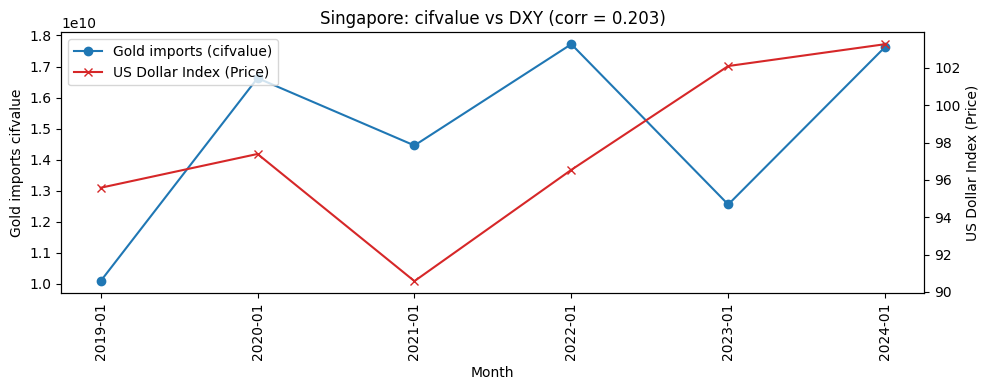

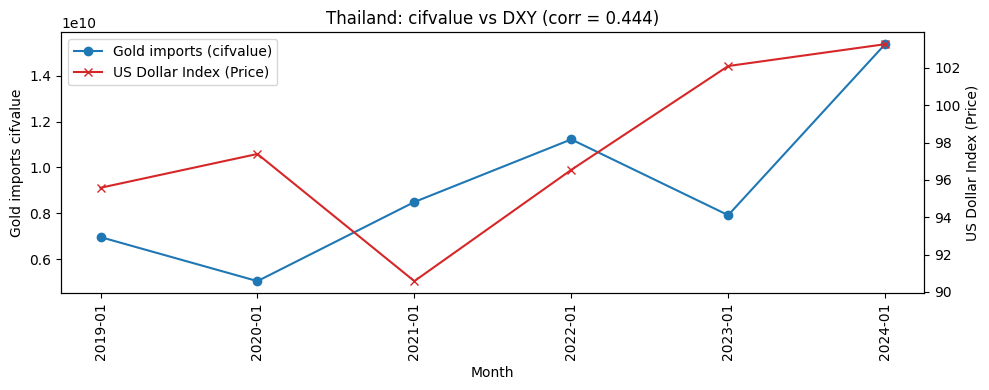

In [47]:
def plot_country_timeseries(country_code):
    tmp = (
        country_monthly[country_monthly['reporterdesc'] == country_code]
        .merge(dxy_monthly, on='month', how='inner')
        .sort_values('month')
    )
    
    if tmp.empty:
        print(f"No overlapping data for {country_code}")
        return
    
    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    # Left axis: monthly gold import cifvalue
    ax1.plot(
        tmp['month'].astype(str),
        tmp['cifvalue'],
        label='Gold imports (cifvalue)',
        marker='o'
    )
    ax1.set_ylabel('Gold imports cifvalue')
    ax1.set_xlabel('Month')
    ax1.tick_params(axis='x', rotation=90)
    
    # Right axis: US Dollar Index Price
    ax2 = ax1.twinx()
    ax2.plot(
        tmp['month'].astype(str),
        tmp['Price'],
        color='tab:red',
        label='US Dollar Index (Price)',
        marker='x'
    )
    ax2.set_ylabel('US Dollar Index (Price)')
    
    # Title with correlation coefficient if available
    corr_val = tmp[['cifvalue', 'Price']].corr().iloc[0, 1]
    plt.title(f"{country_code}: cifvalue vs DXY (corr = {corr_val:.3f})")
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Plot for all top 10 countries
for c in top10_countries:
    plot_country_timeseries(c)
